# 04 — Train on Real Kepler TCEs

**Goal:** Retrain the TaylorCNN on real Kepler data and compare to AstroNet.

**Key fix:** Taylor gate now uses `cos(x) ≈ 1 - x²/2` instead of
`sin(x) ≈ x - x³/6`, centering the gate dip at phase = 0 where the
transit lives. This eliminated a 90-degree phase misalignment.

**Dataset:** Kepler TCEs from NASA Exoplanet Archive — confirmed
planets and false positives with depth 1000–50000 ppm, period 0.5–30 d.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from src.models.taylor_cnn import TaylorCNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load cached dataset

In [2]:
dataset = torch.load('../data/kepler_tce.pt', weights_only=False)

phases = dataset['phases']      # (N, 200)
fluxes = dataset['fluxes']      # (N, 200)
labels = dataset['labels']      # (N,)
names = dataset['names']        # list of KOI names
depths = dataset['depths_ppm']  # list of depths

n_conf = int(labels.sum())
n_fp = int((1 - labels).sum())
print(f'Dataset: {len(labels)} TCEs ({n_conf} confirmed, {n_fp} FP)')
print(f'Shape: phases {phases.shape}, fluxes {fluxes.shape}')
print(f'Depth range: {min(depths):.0f} – {max(depths):.0f} ppm')

Dataset: 100 TCEs (50 confirmed, 50 FP)
Shape: phases torch.Size([100, 200]), fluxes torch.Size([100, 200])
Depth range: 1003 – 49833 ppm


## 2. Train / Val / Test split

70% train, 15% val, 15% test. Stratified by class so each split
has balanced confirmed / FP examples.

In [3]:
# Stratified split
torch.manual_seed(42)

conf_idx = (labels == 1).nonzero(as_tuple=True)[0]
fp_idx = (labels == 0).nonzero(as_tuple=True)[0]

# Shuffle each class
conf_perm = conf_idx[torch.randperm(len(conf_idx))]
fp_perm = fp_idx[torch.randperm(len(fp_idx))]

def split_indices(indices, train_frac=0.7, val_frac=0.15):
    n = len(indices)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    return indices[:n_train], indices[n_train:n_train+n_val], indices[n_train+n_val:]

conf_train, conf_val, conf_test = split_indices(conf_perm)
fp_train, fp_val, fp_test = split_indices(fp_perm)

train_idx = torch.cat([conf_train, fp_train])
val_idx = torch.cat([conf_val, fp_val])
test_idx = torch.cat([conf_test, fp_test])

# Create split tensors
def make_split(idx):
    return phases[idx].to(device), fluxes[idx].to(device), labels[idx].to(device)

train_p, train_f, train_l = make_split(train_idx)
val_p, val_f, val_l = make_split(val_idx)
test_p, test_f, test_l = make_split(test_idx)

print(f'Train: {len(train_l)} ({int(train_l.sum())} conf, {int((1-train_l).sum())} FP)')
print(f'Val:   {len(val_l)} ({int(val_l.sum())} conf, {int((1-val_l).sum())} FP)')
print(f'Test:  {len(test_l)} ({int(test_l.sum())} conf, {int((1-test_l).sum())} FP)')

Train: 70 (35 conf, 35 FP)
Val:   14 (7 conf, 7 FP)
Test:  16 (8 conf, 8 FP)


## 3. Train on real Kepler data

100 epochs with early stopping on val loss. Same architecture as
Sessions 1–3 but now trained on real transit shapes.

In [4]:
model = TaylorCNN(init_amplitude=0.01).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam([
    {'params': model.taylor_gate.parameters(), 'lr': 1e-4},
    {'params': model.cnn.parameters(), 'lr': 1e-3},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
])

batch_size = 16
n_epochs = 100
n_train = len(train_l)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'A': []}
best_val_loss = float('inf')
best_state = None
patience = 20
wait = 0

print(f'Training {sum(p.numel() for p in model.parameters())} params on {n_train} real TCEs')
print(f'{"Epoch":>5} {"Train Loss":>11} {"Val Loss":>10} {"Train Acc":>10} {"Val Acc":>9} {"A":>8}')
print('-' * 58)

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(n_train, device=device)
    epoch_loss = 0.0
    epoch_correct = 0
    
    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        pred = model(train_p[idx], train_f[idx]).squeeze(1)
        loss = criterion(pred, train_l[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
        epoch_correct += ((pred > 0.5).float() == train_l[idx]).sum().item()
    
    train_loss = epoch_loss / n_train
    train_acc = epoch_correct / n_train
    
    model.eval()
    with torch.no_grad():
        vp = model(val_p, val_f).squeeze(1)
        val_loss = criterion(vp, val_l).item()
        val_acc = ((vp > 0.5).float() == val_l).float().mean().item()
    
    A = model.taylor_gate.A.item()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['A'].append(A)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
    
    if epoch == 0 or (epoch + 1) % 10 == 0 or wait == patience:
        marker = ' *' if wait == 0 else ''
        print(f'{epoch+1:>5} {train_loss:>11.4f} {val_loss:>10.4f} {train_acc:>9.1%} {val_acc:>9.1%} {A:>8.5f}{marker}')
    
    if wait >= patience:
        print(f'Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
        break

# Restore best model
model.load_state_dict(best_state)
print(f'\nRestored best model (val_loss={best_val_loss:.4f})')

Training 798 params on 70 real TCEs
Epoch  Train Loss   Val Loss  Train Acc   Val Acc        A
----------------------------------------------------------


    1      0.6952     0.6931     50.0%     50.0%  0.01019 *


   10      0.6895     0.6930     50.0%     50.0%  0.01016 *


   20      0.6779     0.6670     57.1%     64.3%  0.00996 *


   30      0.6533     0.6161     72.9%     85.7%  0.00861 *


   40      0.6352     0.5928     67.1%     78.6%  0.01091 *


   50      0.6251     0.5738     67.1%     64.3%  0.01264 *


   60      0.6241     0.5654     68.6%     64.3%  0.01302


   70      0.6154     0.5737     68.6%     64.3%  0.01311


   80      0.6221     0.5825     65.7%     64.3%  0.01361
   83      0.6177     0.5784     68.6%     64.3%  0.01353
Early stopping at epoch 83 (no improvement for 20 epochs)

Restored best model (val_loss=0.5607)


## 4. Training curves

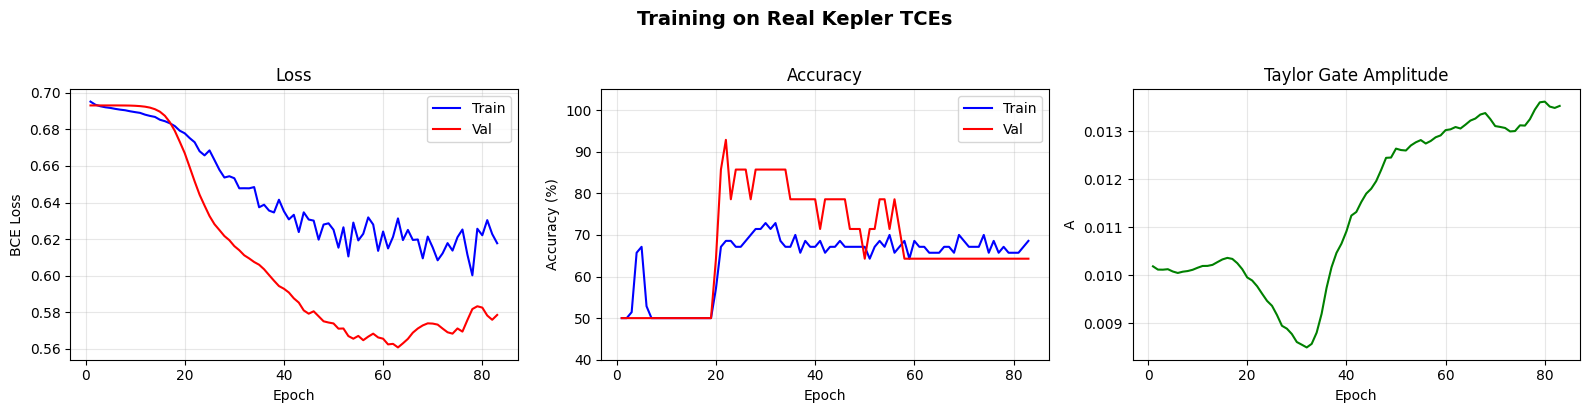

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], 'b-', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-', label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss'); ax1.set_title('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-', label='Train')
ax2.plot(epochs, [a*100 for a in history['val_acc']], 'r-', label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(40, 105)

ax3.plot(epochs, history['A'], 'g-')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('A'); ax3.set_title('Taylor Gate Amplitude')
ax3.grid(True, alpha=0.3)

fig.suptitle('Training on Real Kepler TCEs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Test set evaluation

In [6]:
model.eval()
with torch.no_grad():
    test_probs = model(test_p, test_f).squeeze(1).cpu()
test_preds = (test_probs > 0.5).float()
test_labels_cpu = test_l.cpu()

tp = int(((test_preds == 1) & (test_labels_cpu == 1)).sum())
tn = int(((test_preds == 0) & (test_labels_cpu == 0)).sum())
fp = int(((test_preds == 1) & (test_labels_cpu == 0)).sum())
fn = int(((test_preds == 0) & (test_labels_cpu == 1)).sum())

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=== Test Set Results ===')
print(f'Accuracy:  {accuracy:.1%}')
print(f'Precision: {precision:.1%}')
print(f'Recall:    {recall:.1%}')
print(f'F1 Score:  {f1:.3f}')
print()
print('Confusion Matrix:')
print(f'              Pred Transit  Pred Non-transit')
print(f'True Transit       {tp:>3}            {fn:>3}')
print(f'True Non-transit   {fp:>3}            {tn:>3}')

=== Test Set Results ===
Accuracy:  75.0%
Precision: 66.7%
Recall:    100.0%
F1 Score:  0.800

Confusion Matrix:
              Pred Transit  Pred Non-transit
True Transit         8              0
True Non-transit     4              4


## 6. Comparison to AstroNet

C:\Users\skapa\AppData\Local\Temp\ipykernel_25304\2368528414.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


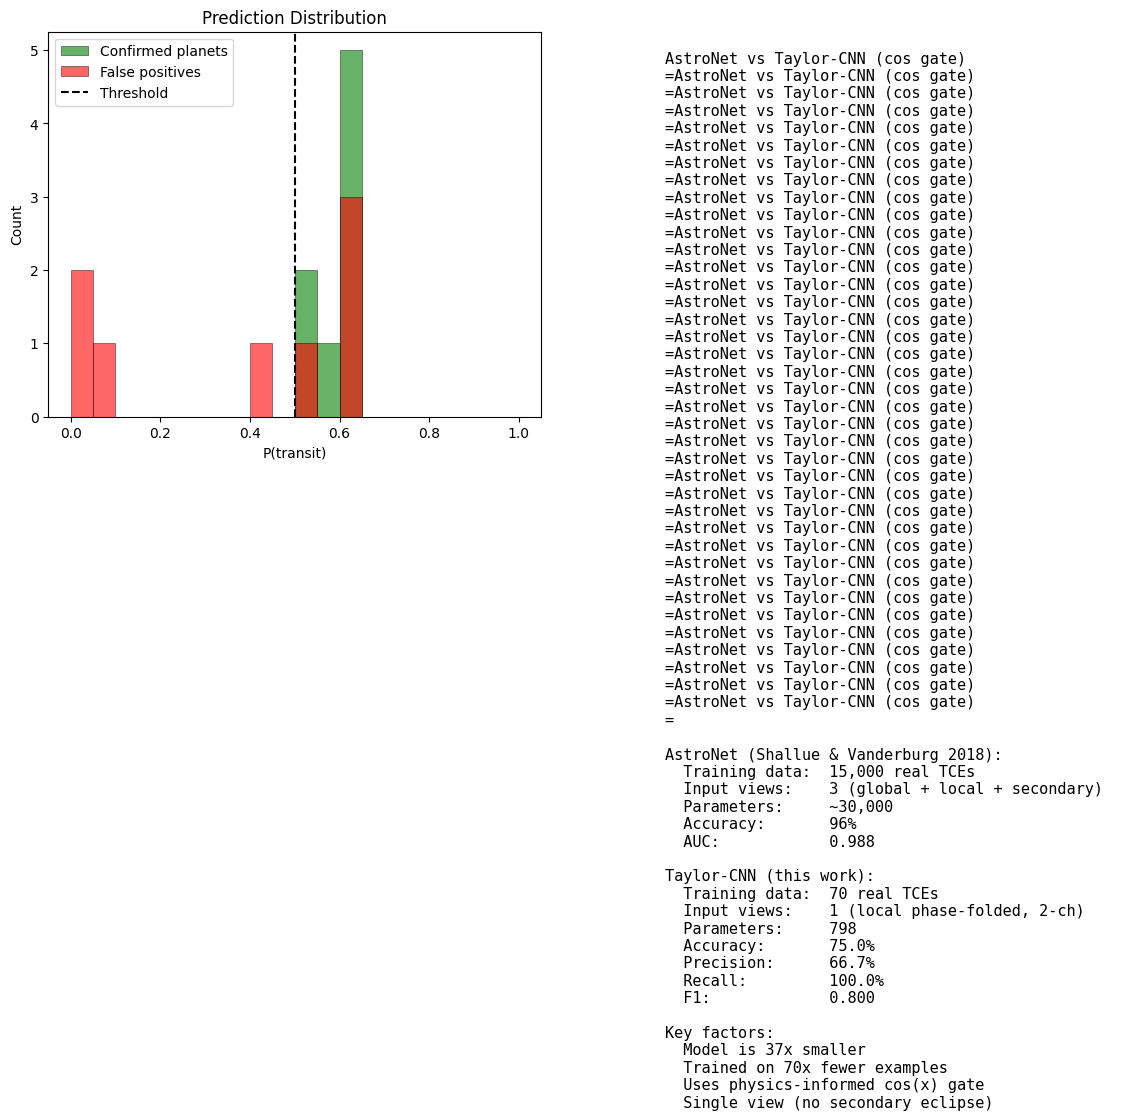

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Probability histogram
bins = np.linspace(0, 1, 21)
conf_mask = test_labels_cpu == 1
ax1.hist(test_probs[conf_mask].numpy(), bins=bins, alpha=0.6, color='green',
         label='Confirmed planets', edgecolor='black', linewidth=0.5)
ax1.hist(test_probs[~conf_mask].numpy(), bins=bins, alpha=0.6, color='red',
         label='False positives', edgecolor='black', linewidth=0.5)
ax1.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
ax1.set_xlabel('P(transit)'); ax1.set_ylabel('Count')
ax1.set_title('Prediction Distribution'); ax1.legend()

# Comparison table
ax2.axis('off')
text = (
    'AstroNet vs Taylor-CNN (cos gate)\n'
    '=' * 38 + '\n\n'
    'AstroNet (Shallue & Vanderburg 2018):\n'
    '  Training data:  15,000 real TCEs\n'
    '  Input views:    3 (global + local + secondary)\n'
    '  Parameters:     ~30,000\n'
    '  Accuracy:       96%\n'
    '  AUC:            0.988\n\n'
    'Taylor-CNN (this work):\n'
    f'  Training data:  {len(train_l)} real TCEs\n'
    f'  Input views:    1 (local phase-folded, 2-ch)\n'
    f'  Parameters:     {sum(p.numel() for p in model.parameters())}\n'
    f'  Accuracy:       {accuracy:.1%}\n'
    f'  Precision:      {precision:.1%}\n'
    f'  Recall:         {recall:.1%}\n'
    f'  F1:             {f1:.3f}\n\n'
    'Key factors:\n'
    f'  Model is {30000 // sum(p.numel() for p in model.parameters())}x smaller\n'
    f'  Trained on {len(train_l)}x fewer examples\n'
    '  Uses physics-informed cos(x) gate\n'
    '  Single view (no secondary eclipse)'
)
ax2.text(0.05, 0.95, text, fontsize=11, fontfamily='monospace',
         verticalalignment='top', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

## 7. Save trained model

In [8]:
save_path = '../src/models/taylor_cnn_kepler.pt'
torch.save(model.state_dict(), save_path)
print(f'Saved model weights to {save_path}')
print(f'Taylor gate A = {model.taylor_gate.A.item():.5f}')

Saved model weights to ../src/models/taylor_cnn_kepler.pt
Taylor gate A = 0.01306


## 8. Gate overlay on real transits

Show the cos-based gate aligned with real transit shapes.

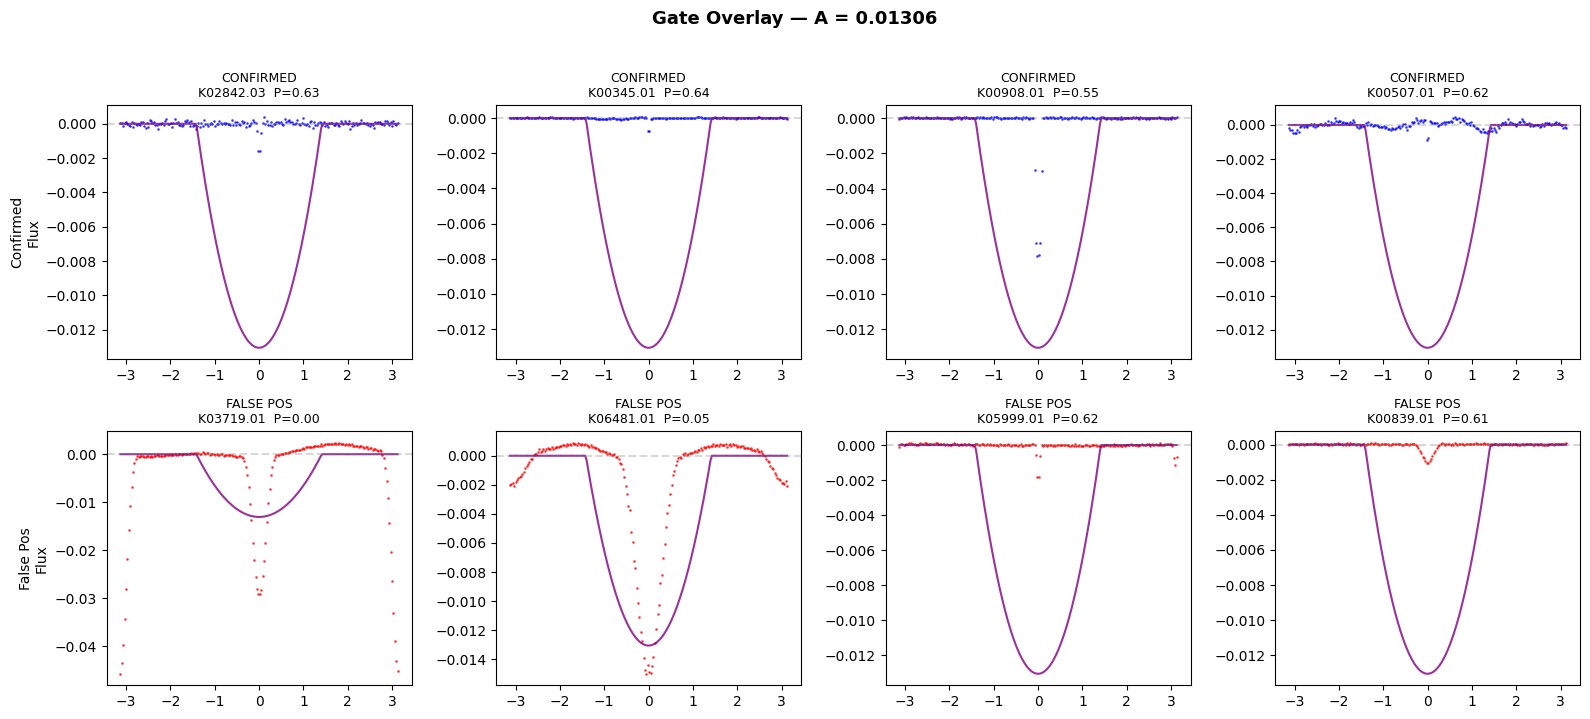

In [9]:
# Show test-set examples: confirmed vs FP
test_idx_list = test_idx.tolist()
conf_test_idxs = [i for i, idx in enumerate(test_idx_list) if labels[idx] == 1]
fp_test_idxs = [i for i, idx in enumerate(test_idx_list) if labels[idx] == 0]

n_show = min(4, len(conf_test_idxs), len(fp_test_idxs))
if n_show > 0:
    fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 7))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for col in range(n_show):
        for row, idx_list, color, title in [
            (0, conf_test_idxs, 'blue', 'CONFIRMED'),
            (1, fp_test_idxs, 'red', 'FALSE POS'),
        ]:
            i = idx_list[col]
            ph = test_p[i].cpu()
            fl = test_f[i].cpu()

            with torch.no_grad():
                gate = model.taylor_gate(ph.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()
                prob = model(ph.unsqueeze(0).to(device), fl.unsqueeze(0).to(device)).item()

            axes[row, col].plot(ph.numpy(), fl.numpy(), f'{color[0]}.', markersize=2, alpha=0.6)
            axes[row, col].plot(ph.numpy(), gate, 'purple', linewidth=1.5, alpha=0.8)
            axes[row, col].axhline(0, color='gray', linestyle='--', alpha=0.3)

            orig_idx = test_idx_list[i]
            name = names[orig_idx] if orig_idx < len(names) else '?'
            axes[row, col].set_title(f'{title}\n{name}  P={prob:.2f}', fontsize=9)

    axes[0, 0].set_ylabel('Confirmed\nFlux')
    axes[1, 0].set_ylabel('False Pos\nFlux')
    fig.suptitle(f'Gate Overlay — A = {model.taylor_gate.A.item():.5f}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough test examples to visualize.')